In [1]:
import pandas as pd

df = pd.read_csv("/Users/senarajayawardena/Desktop/IIT 2y/SEM 02/Data Science /ICW/Data Science/UN_SDG_ER_RSK_LBREDS.csv")

print("Shape:", df.shape)

Shape: (3588, 41)


In [2]:
print("Columns:", df.columns.tolist())

Columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL']


In [3]:
print(df.dtypes)

STRUCTURE                  object
STRUCTURE_ID               object
ACTION                     object
FREQ                       object
REF_AREA                   object
INDICATOR                  object
SEX                        object
AGE                        object
URBANISATION               object
UNIT_MEASURE               object
COMP_BREAKDOWN_1           object
COMP_BREAKDOWN_2           object
COMP_BREAKDOWN_3           object
TIME_PERIOD                 int64
OBS_VALUE                 float64
AGG_METHOD                 object
UNIT_TYPE                  object
DECIMALS                    int64
DATABASE_ID                object
TIME_FORMAT                 int64
UNIT_MULT                   int64
OBS_STATUS                 object
OBS_CONF                   object
FREQ_LABEL                 object
REF_AREA_LABEL             object
INDICATOR_LABEL            object
SEX_LABEL                  object
AGE_LABEL                  object
URBANISATION_LABEL         object
UNIT_MEASURE_L

In [4]:
print(df.isnull().sum())

STRUCTURE                    0
STRUCTURE_ID                 0
ACTION                       0
FREQ                         0
REF_AREA                     0
INDICATOR                    0
SEX                          0
AGE                          0
URBANISATION                 0
UNIT_MEASURE                 0
COMP_BREAKDOWN_1             0
COMP_BREAKDOWN_2             0
COMP_BREAKDOWN_3             0
TIME_PERIOD                  0
OBS_VALUE                 1222
AGG_METHOD                   0
UNIT_TYPE                    0
DECIMALS                     0
DATABASE_ID                  0
TIME_FORMAT                  0
UNIT_MULT                    0
OBS_STATUS                   0
OBS_CONF                     0
FREQ_LABEL                   0
REF_AREA_LABEL               0
INDICATOR_LABEL              0
SEX_LABEL                    0
AGE_LABEL                    0
URBANISATION_LABEL           0
UNIT_MEASURE_LABEL           0
COMP_BREAKDOWN_1_LABEL       0
COMP_BREAKDOWN_2_LABEL       0
COMP_BRE

In [5]:
# Keep only useful columns
df = df[["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE", "OBS_STATUS_LABEL"]]


In [6]:
# Rename
df = df.rename(columns={
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "pct_at_risk",
    "OBS_STATUS_LABEL": "status"
})

In [7]:
# Drop missing values
df = df.dropna(subset=["pct_at_risk"])

In [8]:
# Fix types
df["year"] = df["year"].astype(int)
df["pct_at_risk"] = df["pct_at_risk"].astype(float)
df["country"] = df["country"].str.strip()


In [9]:
# Drop duplicates
df = df.drop_duplicates()

In [10]:
# Save cleaned file
df.to_csv("clean.csv", index=False)
print("Saved to clean.csv")

Saved to clean.csv


EDA

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("clean.csv")

In [12]:
print("Shape:", df.shape)
print(df.describe())
print(df.isnull().sum())

Shape: (2366, 4)
              year  pct_at_risk
count  2366.000000  2366.000000
mean   2011.368555    49.478022
std       7.557996    37.445528
min    2000.000000     0.000000
25%    2005.000000    11.000000
50%    2010.000000    50.000000
75%    2018.000000    86.000000
max    2025.000000   100.000000
country        0
year           0
pct_at_risk    0
status         0
dtype: int64


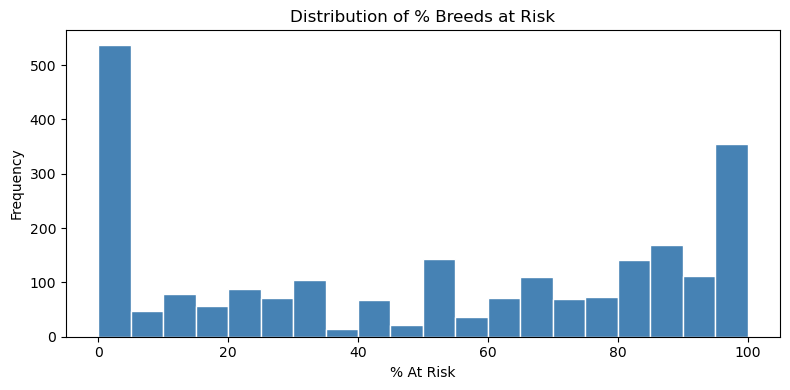

In [14]:
plt.figure(figsize=(8, 4))
df["pct_at_risk"].plot(kind="hist", bins=20, color="steelblue", edgecolor="white")
plt.title("Distribution of % Breeds at Risk")
plt.xlabel("% At Risk")
plt.tight_layout()
plt.show()

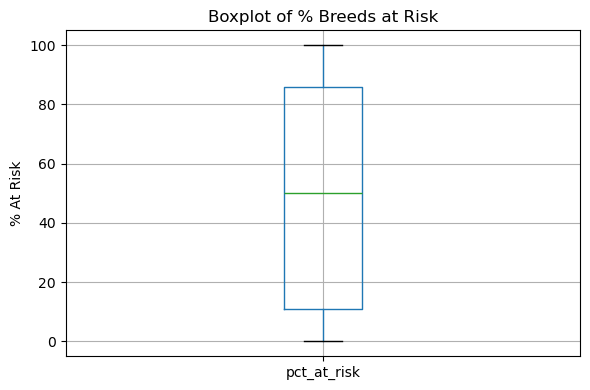

In [15]:
plt.figure(figsize=(6, 4))
df.boxplot(column="pct_at_risk")
plt.title("Boxplot of % Breeds at Risk")
plt.ylabel("% At Risk")
plt.tight_layout()
plt.show()

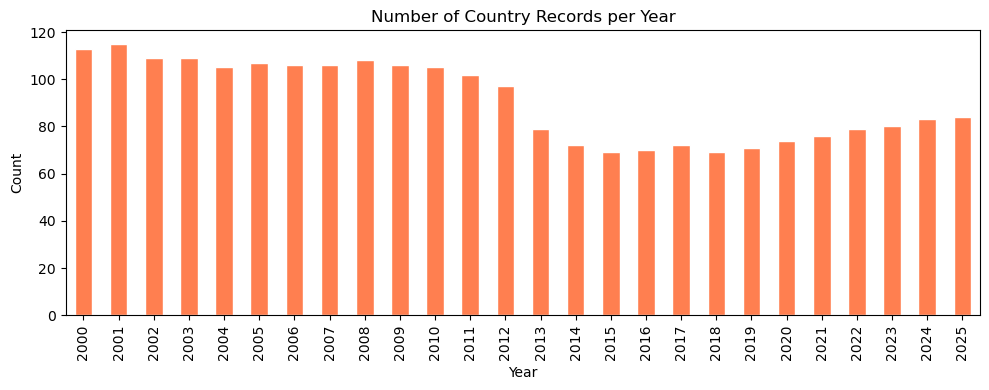

In [16]:
plt.figure(figsize=(10, 4))
df["year"].value_counts().sort_index().plot(kind="bar", color="coral", edgecolor="white")
plt.title("Number of Country Records per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

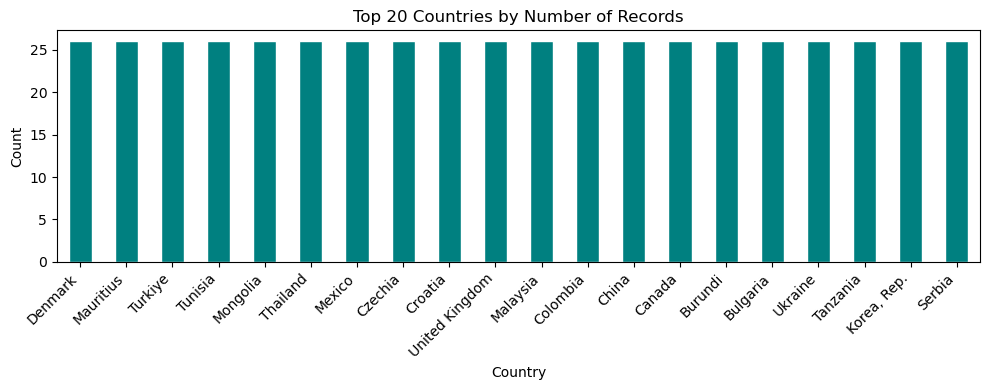

In [17]:
plt.figure(figsize=(10, 4))
df["country"].value_counts().head(20).plot(kind="bar", color="teal", edgecolor="white")
plt.title("Top 20 Countries by Number of Records")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

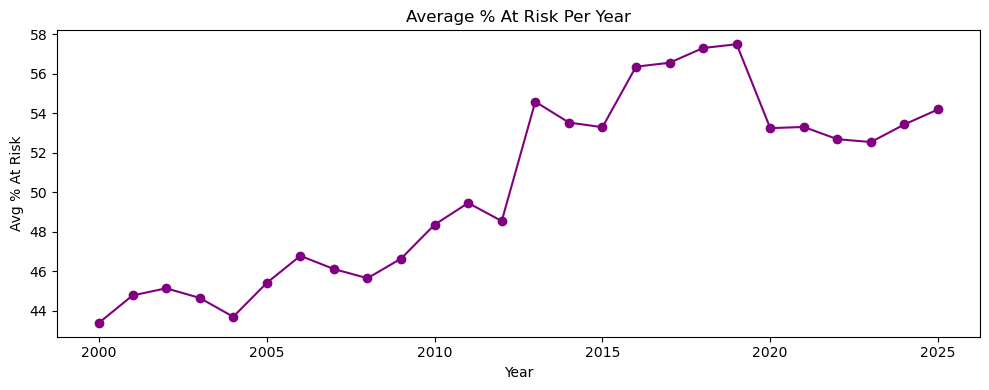

In [18]:
plt.figure(figsize=(10, 4))
df.groupby("year")["pct_at_risk"].mean().plot(kind="line", marker="o", color="purple")
plt.title("Average % At Risk Per Year")
plt.xlabel("Year")
plt.ylabel("Avg % At Risk")
plt.tight_layout()
plt.show()